# DAR fiber-flux-loss — figure reproduction from the local dataset

Reproduces the key focal-plane figures from the NERSC DAR study **starting from the
saved dataset only** (`notebooks/data/dar_calibstars_dataset.parquet`) — no database
or data-selection step, and no dependency on the `telemetry_mining` package.

The original per-exposure analysis was done with throwaway scripts that were never
archived; what *was* archived is the pooled per-star dataset (one row per VALID
standard-star measurement), the report (`DAR_FIBER_LOSS_REPORT.md`), and the PNG
figures under `notebooks/figures/`. This notebook rebuilds the analysis figures from
that dataset.

**Figures produced**
1. All-exposures per-star focal-plane flux-loss scatter (`dar_fig_all_combined_scatter`)
2. Seeing×airmass focal-plane hexbin grid (`dar_fig_seeing_x_airmass_focalplane`)
3. Post-positioning-change row: `night > 20260307`, seeing-integrated (`dar_fig_post_positioning_change_focalplane`)
4. **New** — the same row for exposures *before* that date, plus a stacked
   before-vs-after comparison on a shared color scale (1-to-1 comparison).

`loss = 1 - RCALIBFRAC`: **red = flux loss** (target drifted off the fiber),
**blue = excess** (more flux than the calibration expects).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.patches import Circle
from matplotlib.cm import ScalarMappable

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

## 1. Load the dataset

The loader is copied inline (rather than importing `load_dar_dataset.py`) so this
notebook is self-contained. It reads the Parquet file if `pyarrow`/`fastparquet` is
available and otherwise falls back to the gzipped CSV — both live in `notebooks/data/`.

In [2]:
DATA_DIR = os.path.join(os.getcwd(), "data")
PARQUET_PATH = os.path.join(DATA_DIR, "dar_calibstars_dataset.parquet")
CSV_PATH = os.path.join(DATA_DIR, "dar_calibstars_dataset.csv.gz")


def load_dar_calibstars():
    """Pooled per-star DAR/fiber-flux-loss dataset as a DataFrame.

    One row per VALID standard-star measurement across every DESI
    DARK/BRIGHT/DARK1B/BRIGHT1B science exposure fetched. Columns:
    EXPID, FIBER, PETAL (=FIBER//500), X, Y (focal-plane mm), radius,
    RCALIBFRAC, loss (=1-RCALIBFRAC), airmass, seeing, night (YYYYMMDD int).
    """
    try:
        return pd.read_parquet(PARQUET_PATH)
    except (ImportError, ValueError):
        return pd.read_csv(CSV_PATH)


df = load_dar_calibstars()
print(f"rows (star measurements): {len(df):,}")
print(f"exposures:                {df.EXPID.nunique():,}")
print(f"night range:              {df.night.min()} .. {df.night.max()}")
print(f"airmass range:            {df.airmass.min():.3f} .. {df.airmass.max():.3f}")
df.head(3)

rows (star measurements): 2,570,324
exposures:                24,630
night range:              20210917 .. 20260719
airmass range:            1.000 .. 2.316


,EXPID,FIBER,PETAL,X,Y,radius,RCALIBFRAC,loss,airmass,seeing,night
0,100712,364,0,44.425411,-371.807556,374.452235,0.900073,0.099927,1.228078,0.83,20210917
1,100712,8,0,74.027138,-287.068481,296.459660,1.047925,-0.047925,1.228078,0.83,20210917
2,100712,162,0,25.927799,-327.214294,328.239920,1.044602,-0.044602,1.228078,0.83,20210917


## Shared configuration and plotting helpers

Everything below is driven by these constants and the two helper functions, so the
before/after comparison uses an identical code path (only the row subset changes).

In [3]:
# Focal-plane radius (mm) for the dashed boundary circle and hexbin extent.
FP_RADIUS = float(np.ceil(df.radius.max() / 10) * 10)   # ~410 mm

# Diverging color limit for 1 - RCALIBFRAC.  The per-star 1/99th percentiles are
# about +/-0.12, so +/-0.13 matches the original figures' saturation.
VMAX = 0.13
CMAP = "RdBu_r"          # red = loss (high), blue = excess (low)
GRIDSIZE = 25           # hexbin resolution across the focal plane

# Airmass binning.  8 bins over [1.00, 2.05) reproduce the post-positioning figure
# (the handful of exposures above 2.05 are dropped, as in the original).
AIRMASS_EDGES = np.linspace(1.0, 2.05, 9)
# The seeing x airmass grid additionally shows a final [2.05, max] catch bin.
AIRMASS_EDGES_GRID = np.append(AIRMASS_EDGES, np.ceil(df.airmass.max() * 100) / 100)

# Seeing rows for the grid (arcsec).  seeing < 1.0 and NaN seeing are excluded.
SEEING_EDGES = [1.0, 1.3, 1.8, np.inf]
SEEING_LABELS = ["seeing 1.0-1.3", "seeing 1.3-1.8", "seeing 1.8-inf"]

# Night of the fiber-positioning code change used to split before/after.
SPLIT_NIGHT = 20260307

print(f"FP_RADIUS = {FP_RADIUS} mm   VMAX = {VMAX}")
print("airmass edges (rows):", np.round(AIRMASS_EDGES, 3))
print("airmass edges (grid):", np.round(AIRMASS_EDGES_GRID, 3))

FP_RADIUS = 420.0 mm   VMAX = 0.13
airmass edges (rows): [1.    1.131 1.262 1.394 1.525 1.656 1.787 1.919 2.05 ]
airmass edges (grid): [1.    1.131 1.262 1.394 1.525 1.656 1.787 1.919 2.05  2.32 ]


In [4]:
def _focalplane_axes(ax):
    """Common focal-plane panel styling: equal aspect, no ticks, dashed FOV circle."""
    lim = FP_RADIUS * 1.03
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.add_patch(Circle((0, 0), FP_RADIUS, fill=False, ls="--", lw=0.6, ec="0.5"))


def focalplane_airmass_grid(rows, airmass_edges, suptitle, vmax=VMAX,
                            gridsize=GRIDSIZE, per_panel_stars=True, demean=False):
    """Grid of focal-plane hexbin panels: one row per (label, subset), one
    column per airmass bin.  Each hex is colored by the mean `loss` of the
    stars in it.  All panels share the diverging norm [-vmax, +vmax].

    `rows` : list of (row_label, DataFrame).  Passing a single row reproduces the
    post-positioning figure; passing before+after gives the 1-to-1 comparison.
    """
    ncol = len(airmass_edges) - 1
    nrow = len(rows)
    norm = Normalize(-vmax, vmax)
    fig, axes = plt.subplots(nrow, ncol, squeeze=False,
                             figsize=(2.05 * ncol, 2.35 * nrow))
    for i, (row_label, rdf) in enumerate(rows):
        for j in range(ncol):
            lo, hi = airmass_edges[j], airmass_edges[j + 1]
            sub = rdf[(rdf.airmass >= lo) & (rdf.airmass < hi)]
            ax = axes[i][j]
            _focalplane_axes(ax)
            if len(sub):
                cvals = sub.loss.values
                if demean:                      # remove this panel's overall mean loss
                    cvals = cvals - sub.loss.mean()
                ax.hexbin(sub.X, sub.Y, C=cvals,
                          reduce_C_function=np.mean, gridsize=gridsize,
                          extent=(-FP_RADIUS, FP_RADIUS, -FP_RADIUS, FP_RADIUS),
                          cmap=CMAP, norm=norm, mincnt=1, linewidths=0.2)
            n_exp = sub.EXPID.nunique()
            title = f"am {lo:.2f}-{hi:.2f}\nn_exp={n_exp}"
            if per_panel_stars:
                title += f", n_stars={len(sub)}"
            ax.set_title(title, fontsize=7)
            if j == 0:
                ax.set_ylabel(row_label, fontsize=9)
    fig.suptitle(suptitle, fontsize=12, y=0.995)
    # One shared colorbar down the right edge.
    sm = ScalarMappable(norm=norm, cmap=CMAP)
    cbar = fig.colorbar(sm, ax=axes, fraction=0.015, pad=0.01)
    lbl = ("mean loss - bin mean  (spatial variation only)" if demean
           else "mean  1 - RCALIBFRAC  (loss; blue=excess, red=loss)")
    cbar.set_label(lbl, fontsize=9)
    return fig


def focalplane_scatter(data, title, vmax=VMAX):
    """Per-star focal-plane scatter colored by `loss` (rasterized for file size)."""
    fig, ax = plt.subplots(figsize=(9, 8))
    ax.scatter(data.X, data.Y, c=data.loss, cmap=CMAP, vmin=-vmax, vmax=vmax,
               s=1, alpha=0.15, linewidths=0, rasterized=True)
    _focalplane_axes(ax)
    ax.set_xticks(np.arange(-400, 401, 200))
    ax.set_yticks(np.arange(-400, 401, 200))
    ax.set_xlabel("X (mm)")
    ax.set_ylabel("Y (mm)")
    ax.set_title(title, fontsize=12)
    sm = ScalarMappable(norm=Normalize(-vmax, vmax), cmap=CMAP)
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("1 - RCALIBFRAC  (per-star loss; blue=excess, red=loss)")
    return fig

## Figure 1 — All exposures / airmass / seeing combined (per-star scatter)

Every VALID standard-star measurement, colored by its own `1 - RCALIBFRAC`. The
discrete 10-fold petal/wedge structure is the qualitative headline of the study.

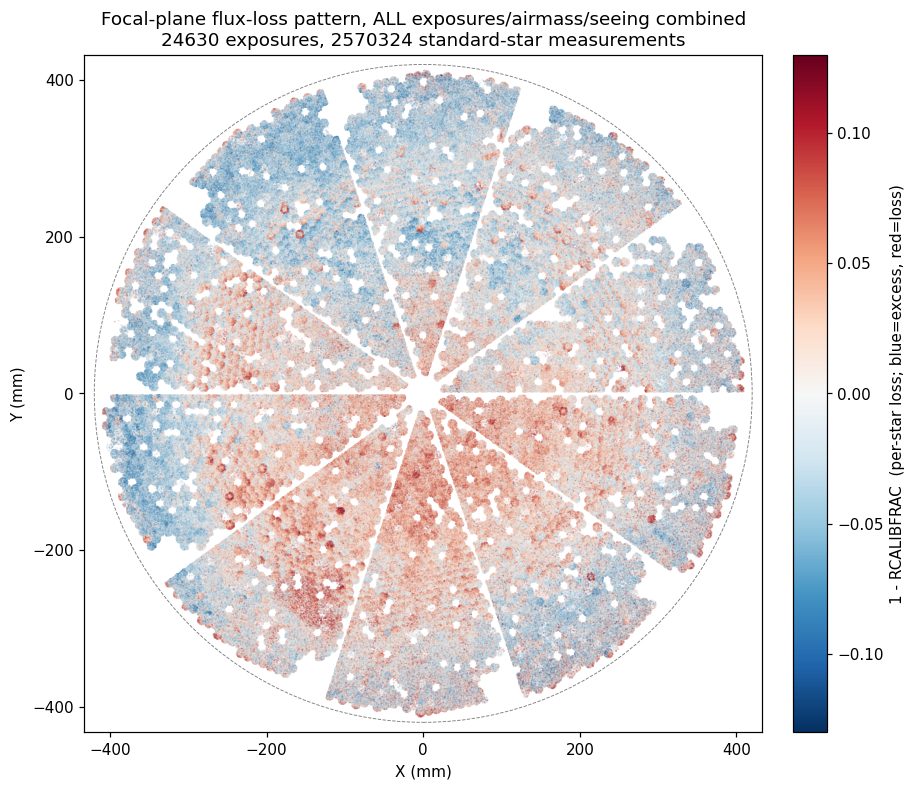

In [5]:
title = ("Focal-plane flux-loss pattern, ALL exposures/airmass/seeing combined\n"
         f"{df.EXPID.nunique()} exposures, {len(df)} standard-star measurements")
fig = focalplane_scatter(df, title)
plt.show()

## Figure 2 — Seeing × airmass focal-plane grid

Rows are seeing bins, columns are airmass bins (including a final `2.05–max` catch
bin). Each hex shows the mean loss. Panels with no exposures in that (seeing, airmass)
cell are left blank. Cells shift red-in-the-south / blue-in-the-north as airmass
increases — the DAR signature — independent of seeing.

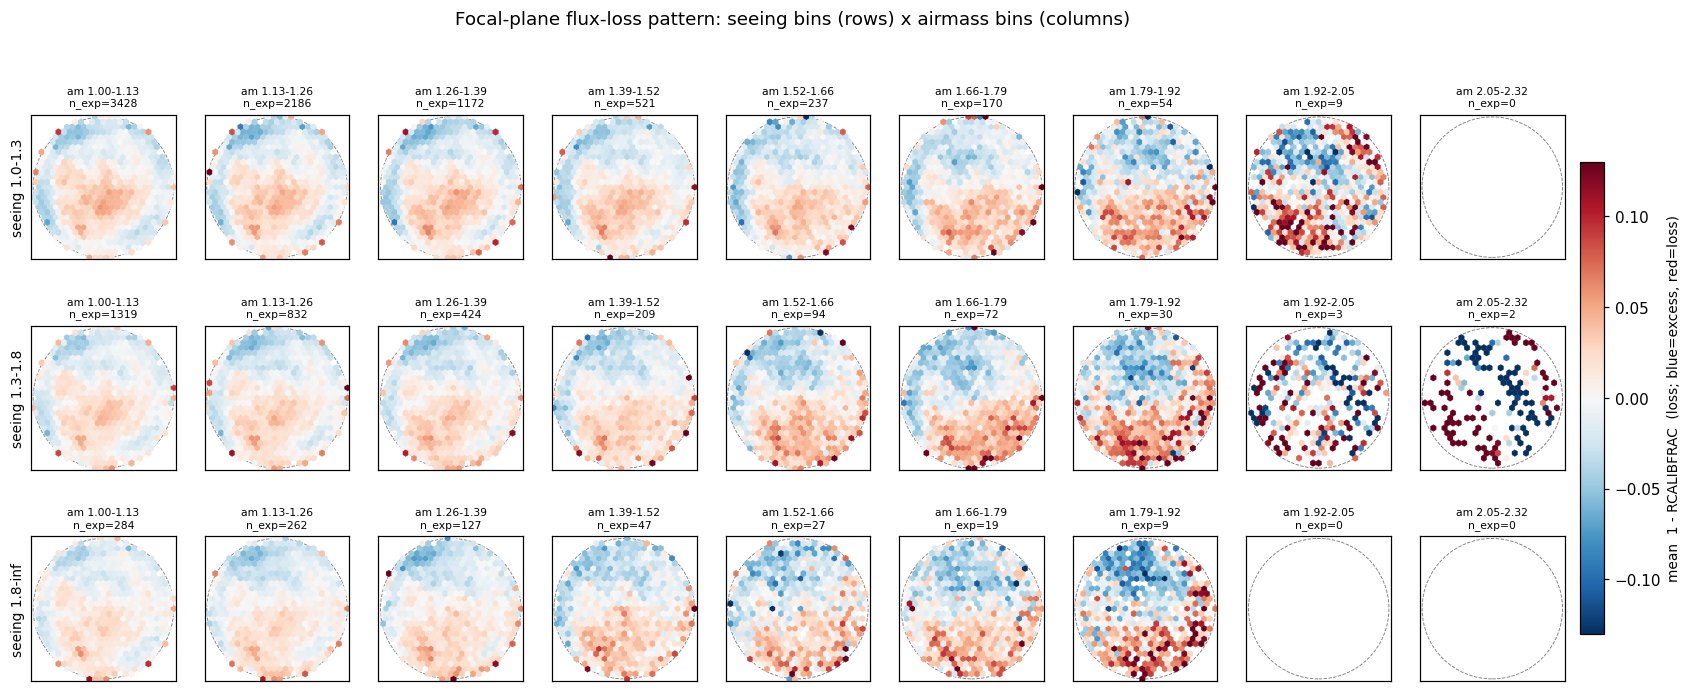

In [6]:
seeing_rows = []
for (lo, hi), label in zip(zip(SEEING_EDGES[:-1], SEEING_EDGES[1:]), SEEING_LABELS):
    seeing_rows.append((label, df[(df.seeing >= lo) & (df.seeing < hi)]))

fig = focalplane_airmass_grid(
    seeing_rows, AIRMASS_EDGES_GRID,
    suptitle="Focal-plane flux-loss pattern: seeing bins (rows) x airmass bins (columns)",
    per_panel_stars=False)
plt.show()

## Figure 3 — Post-positioning-change (night > 20260307), seeing-integrated

Only exposures taken *after* the 2026-03-07 fiber-positioning code change, integrated
over seeing, so the columns are purely airmass bins. This reproduces
`dar_fig_post_positioning_change_focalplane.png` (1657 exposures across the 8 bins).

after 20260307: 1657 exposures, 173697 stars


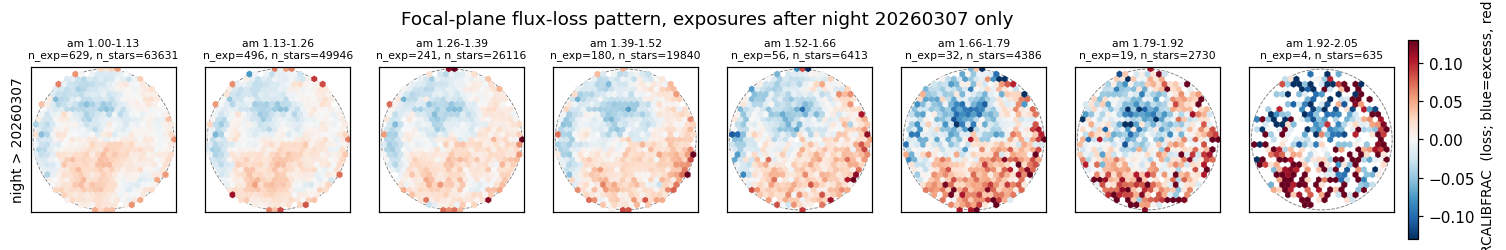

In [7]:
after = df[df.night > SPLIT_NIGHT]
print(f"after {SPLIT_NIGHT}: {after.EXPID.nunique()} exposures, {len(after)} stars")

fig = focalplane_airmass_grid(
    [(f"night > {SPLIT_NIGHT}", after)], AIRMASS_EDGES,
    suptitle=f"Focal-plane flux-loss pattern, exposures after night {SPLIT_NIGHT} only")
plt.show()

## Figure 4 — Before the positioning change (night ≤ 20260307)

Same binning, same color scale, same code path — only the night subset differs — so
this is a 1-to-1 comparison with Figure 3.

before/on 20260307: 22973 exposures, 2396627 stars


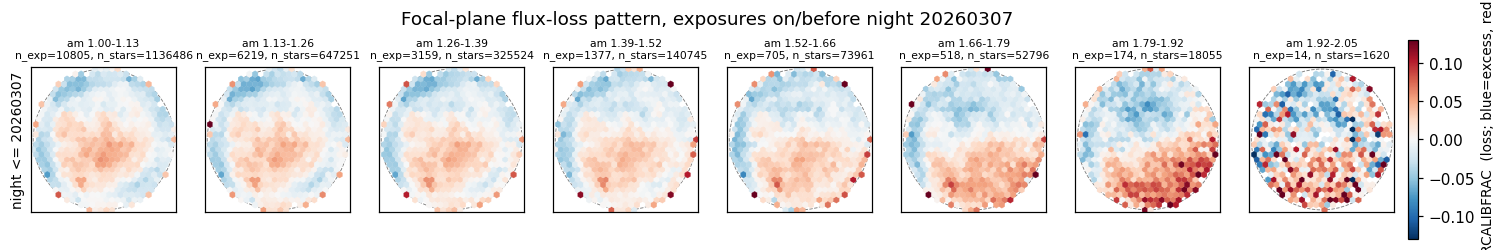

In [8]:
before = df[df.night <= SPLIT_NIGHT]
print(f"before/on {SPLIT_NIGHT}: {before.EXPID.nunique()} exposures, {len(before)} stars")

fig = focalplane_airmass_grid(
    [(f"night <= {SPLIT_NIGHT}", before)], AIRMASS_EDGES,
    suptitle=f"Focal-plane flux-loss pattern, exposures on/before night {SPLIT_NIGHT}")
plt.show()

### Stacked before-vs-after comparison

The two subsets on one shared color scale, top = before, bottom = after. Read down each
column to compare the same airmass bin across the positioning-code change.

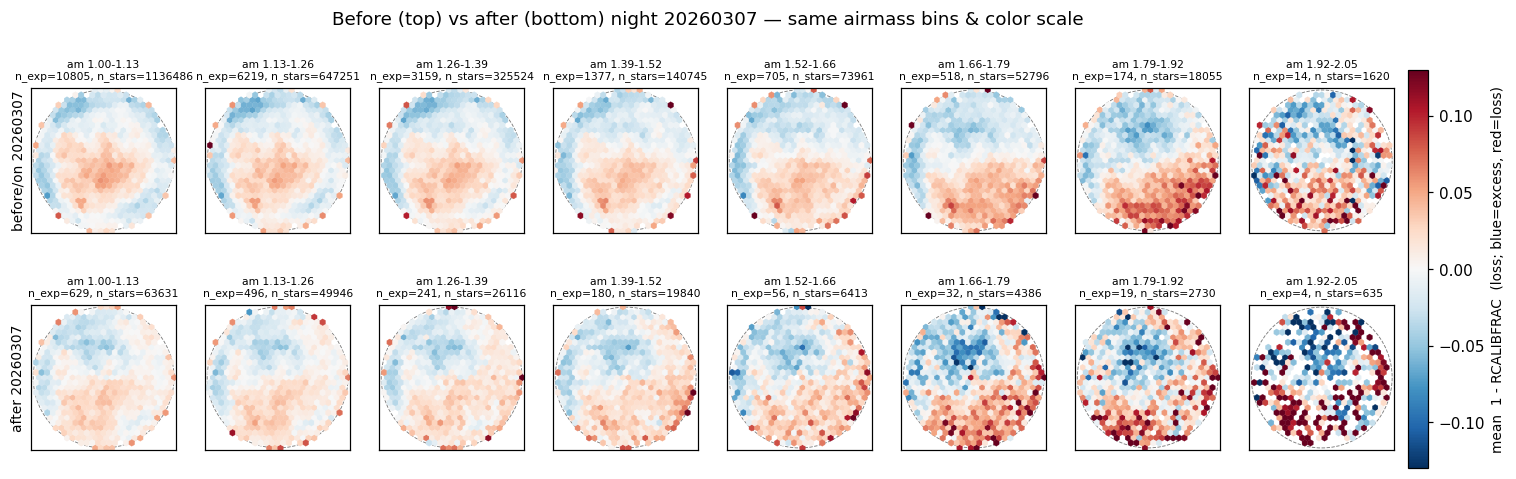

In [9]:
fig = focalplane_airmass_grid(
    [(f"before/on {SPLIT_NIGHT}", before), (f"after {SPLIT_NIGHT}", after)],
    AIRMASS_EDGES,
    suptitle=f"Before (top) vs after (bottom) night {SPLIT_NIGHT} — same airmass bins & color scale")
plt.show()

## 5. Mean-subtracted before/after comparison (spatial variation only)

The overall level of `loss` in each airmass bin (which could be calibration, epoch drift,
or anything else) is not what we want to compare — we want the **spatial pattern**. So we
subtract each panel's own mean loss and show only the deviations from it. This is the same
stacked before/after layout as Figure 4, now displaying `loss - (panel mean)`, which is the
basis for the statistics in Section 6.

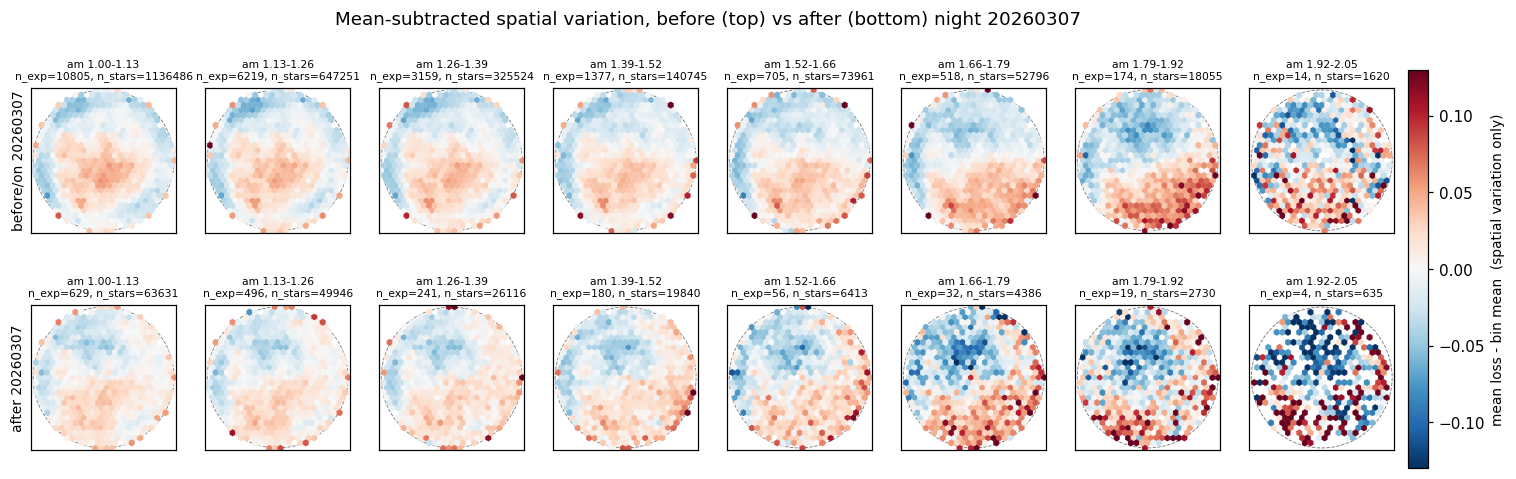

In [10]:
fig = focalplane_airmass_grid(
    [(f"before/on {SPLIT_NIGHT}", before), (f"after {SPLIT_NIGHT}", after)],
    AIRMASS_EDGES,
    suptitle=(f"Mean-subtracted spatial variation, before (top) vs after (bottom) "
              f"night {SPLIT_NIGHT}"),
    demean=True)
plt.show()

## 6. Statistics on the mean-subtracted maps

We tile the focal plane into `CELL_MM`-mm square cells (cells inside the FOV with at least
`MIN_COUNT` stars in **both** epochs). Within each airmass bin we work with the per-cell
mean loss **after removing the bin mean** — i.e. the spatial residual map. No normalization
is applied: amplitudes stay in physical loss units.

### What we compute, and how to read it

**Amplitude of the spatial structure (per epoch):**
- **`exRMS` — excess spatial RMS** = √( mean_k[(m_k − m̄)²] − mean_k[SEM_k²] ). The raw scatter
  of cell means includes measurement noise; subtracting each cell's `SEM² = s²/n` (the
  "simple √n error") leaves the *true* spatial variation amplitude, in loss units.
  - Reading: a value of e.g. 0.02 means loss varies by ~2% RMS across the focal plane beyond
    noise. **If `exRMS` grows with airmass**, the structure is airmass-driven (necessary, not
    sufficient, for a DAR-like origin); if flat, that argues against it.

**Similarity of the pattern (before vs after), all on common cells:**
- **`r` — Pearson correlation** of the before vs after residual maps. Scale-free: r≈1 ⇒ same
  spatial shape (independent of amplitude); r≈0 ⇒ unrelated (real reshaping *or* just noise);
  r<0 ⇒ inverted. `r_dis` is the noise-**disattenuated** value (divided by
  √(reliability_before·reliability_after), where reliability = exVar/rawVar), correcting the
  bias that measurement noise drags r toward 0.
- **`slope`** — least-squares slope of after-residual on before-residual = the amplitude ratio
  of the *shared* pattern. slope>1 ⇒ same shape, stronger after; <1 ⇒ weaker. `slope_dis`
  is disattenuated for predictor noise.
- **`rho` — Spearman rank correlation**: like r but rank-based, robust to a few outlier cells
  and to a non-linear-but-monotonic amplitude change.

**Error bars via bootstrap over *exposures* (not stars).** Stars within one exposure share a
pointing/airmass/DAR state, so they are not independent; resampling **exposures** with
replacement (300×) gives honest 5–95% confidence intervals. This is what tells us whether the
high-airmass "hint" is real: if `r`'s interval there spans ~0 to ~1, the thin statistics
simply cannot distinguish a pattern change from noise.

In [11]:
from scipy import stats as _stats

CELL_MM = 50.0       # square focal-plane cell (mm)
MIN_COUNT = 10       # min stars per cell in BOTH epochs
N_BOOT = 300         # bootstrap resamples (over exposures)
_RNG = np.random.default_rng(0)


def _cell_key(d):
    ix = np.floor((d.X.values + FP_RADIUS) / CELL_MM).astype(int)
    iy = np.floor((d.Y.values + FP_RADIUS) / CELL_MM).astype(int)
    return ix * 100000 + iy


def _cell_agg(d):
    """Per-cell mean / count / std / sem^2 of loss."""
    g = pd.DataFrame({"key": _cell_key(d), "loss": d.loss.values}).groupby("key").loss
    out = g.agg(["mean", "count", "std"])
    out["sem2"] = out["std"] ** 2 / out["count"]
    return out


def _exp_cell_arrays(d, cells):
    """For bootstrap: per (exposure, cell) loss-sum and count, restricted to `cells`.
    Returns exposure-index, cell-position (into `cells`), sum, count arrays."""
    t = pd.DataFrame({"exp": d.EXPID.values, "key": _cell_key(d), "loss": d.loss.values})
    t = t[t.key.isin(cells)]
    g = t.groupby(["exp", "key"]).loss.agg(["sum", "count"]).reset_index()
    exp_codes, exps = pd.factorize(g.exp.values)
    cell_pos = pd.Series(np.arange(len(cells)), index=cells).loc[g.key.values].values
    return exp_codes, len(exps), cell_pos, g["sum"].values, g["count"].values


def _pattern_stats(mb, ma):
    """Pearson r, OLS slope (after on before), Spearman rho for two residual vectors."""
    mb = mb - mb.mean(); ma = ma - ma.mean()
    r = np.corrcoef(mb, ma)[0, 1]
    slope = np.cov(mb, ma, ddof=0)[0, 1] / np.var(mb)
    rho = _stats.spearmanr(mb, ma)[0]
    return r, slope, rho


def _excess_var(mean, sem2):
    return float(np.mean((mean - mean.mean()) ** 2) - np.mean(sem2))


def before_after_variation(before, after, airmass_edges,
                           cell_mm=CELL_MM, min_count=MIN_COUNT, n_boot=N_BOOT):
    global CELL_MM
    CELL_MM = cell_mm
    recs = []
    for lo, hi in zip(airmass_edges[:-1], airmass_edges[1:]):
        bb = before[(before.airmass >= lo) & (before.airmass < hi)]
        aa = after[(after.airmass >= lo) & (after.airmass < hi)]
        b, a = _cell_agg(bb), _cell_agg(aa)
        common = b.index.intersection(a.index)
        common = common[(b.loc[common, "count"] >= min_count) &
                        (a.loc[common, "count"] >= min_count)]
        n = len(common)
        rec = dict(airmass=f"{lo:.2f}-{hi:.2f}", n_cells=n)
        if n < 5:
            recs.append({**rec, **{k: np.nan for k in
                        ["exRMS_b", "exRMS_a", "r", "r_dis", "slope", "slope_dis", "rho",
                         "r_lo", "r_hi", "slope_lo", "slope_hi", "rho_lo", "rho_hi"]}})
            continue
        cells = common.values
        mb0 = b.loc[common, "mean"].values; sb2 = b.loc[common, "sem2"].values
        ma0 = a.loc[common, "mean"].values; sa2 = a.loc[common, "sem2"].values
        exvar_b = _excess_var(mb0, sb2); exvar_a = _excess_var(ma0, sa2)
        rawvar_b = np.var(mb0 - mb0.mean()); rawvar_a = np.var(ma0 - ma0.mean())
        rel_b = np.clip(exvar_b / rawvar_b, 1e-6, 1.0)
        rel_a = np.clip(exvar_a / rawvar_a, 1e-6, 1.0)
        r0, slope0, rho0 = _pattern_stats(mb0, ma0)
        rec.update(exRMS_b=np.sqrt(max(exvar_b, 0)), exRMS_a=np.sqrt(max(exvar_a, 0)),
                   r=r0, r_dis=r0 / np.sqrt(rel_b * rel_a),
                   slope=slope0, slope_dis=slope0 / rel_b, rho=rho0)
        # --- bootstrap over exposures ---
        eb, nb, cb, sumb, cntb = _exp_cell_arrays(bb, cells)
        ea, na_, ca, suma, cnta = _exp_cell_arrays(aa, cells)
        boots = {"r": [], "slope": [], "rho": [], "exRMS_b": [], "exRMS_a": []}
        for _ in range(n_boot):
            wb = _RNG.multinomial(nb, np.full(nb, 1.0 / nb)).astype(float)
            wa = _RNG.multinomial(na_, np.full(na_, 1.0 / na_)).astype(float)
            sb = np.bincount(cb, weights=sumb * wb[eb], minlength=n)
            nbk = np.bincount(cb, weights=cntb * wb[eb], minlength=n)
            sa = np.bincount(ca, weights=suma * wa[ea], minlength=n)
            nak = np.bincount(ca, weights=cnta * wa[ea], minlength=n)
            ok = (nbk > 0) & (nak > 0)
            if ok.sum() < 5:
                continue
            mbk = sb[ok] / nbk[ok]; mak = sa[ok] / nak[ok]
            rr, ss, rh = _pattern_stats(mbk, mak)
            boots["r"].append(rr); boots["slope"].append(ss); boots["rho"].append(rh)
            boots["exRMS_b"].append(np.sqrt(max(
                _excess_var(mbk, sb2[ok]), 0)))
            boots["exRMS_a"].append(np.sqrt(max(_excess_var(mak, sa2[ok]), 0)))
        for key in ["r", "slope", "rho"]:
            arr = np.array(boots[key])
            rec[key + "_lo"], rec[key + "_hi"] = np.percentile(arr, [5, 95])
        for key in ["exRMS_b", "exRMS_a"]:
            arr = np.array(boots[key])
            rec[key + "_lo"], rec[key + "_hi"] = np.percentile(arr, [5, 95])
        recs.append(rec)
    return pd.DataFrame(recs)


var_result = before_after_variation(before, after, AIRMASS_EDGES)

show = var_result.copy()
for c in ["exRMS_b", "exRMS_a"]:
    show[c] = (show[c] * 1e3).round(2)          # milli-units
for c in ["r", "r_dis", "slope", "slope_dis", "rho", "r_lo", "r_hi",
          "slope_lo", "slope_hi", "rho_lo", "rho_hi"]:
    show[c] = show[c].round(2)
print(f"Mean-subtracted spatial-pattern statistics per airmass bin "
      f"(CELL_MM={CELL_MM:g} mm, MIN_COUNT={MIN_COUNT}, {N_BOOT} exposure-bootstraps)")
print("exRMS in milli-units (x1e3); [lo,hi] = 5-95% bootstrap CI\n")
show[["airmass", "n_cells", "exRMS_b", "exRMS_a",
      "r", "r_lo", "r_hi", "r_dis", "slope", "slope_lo", "slope_hi",
      "rho", "rho_lo", "rho_hi"]]

Mean-subtracted spatial-pattern statistics per airmass bin (CELL_MM=50 mm, MIN_COUNT=10, 300 exposure-bootstraps)
exRMS in milli-units (x1e3); [lo,hi] = 5-95% bootstrap CI



,airmass,n_cells,exRMS_b,exRMS_a,r,r_lo,r_hi,r_dis,slope,slope_lo,slope_hi,rho,rho_lo,rho_hi
0,1.00-1.13,235,24.97,18.75,0.58,0.55,0.60,0.59,0.44,0.42,0.47,0.56,0.53,0.59
1,1.13-1.26,232,24.59,19.24,0.61,0.58,0.63,0.62,0.49,0.46,0.51,0.62,0.58,0.63
2,1.26-1.39,226,25.18,20.17,0.62,0.55,0.64,0.64,0.51,0.46,0.57,0.62,0.55,0.64
3,1.39-1.52,224,23.03,24.46,0.62,0.53,0.65,0.64,0.68,0.57,0.75,0.62,0.53,0.65
4,1.52-1.66,207,25.03,27.83,0.70,0.57,0.73,0.76,0.83,0.65,0.96,0.72,0.59,0.75
5,1.66-1.79,200,31.21,43.11,0.80,0.66,0.80,0.87,1.18,0.83,1.58,0.80,0.67,0.81
6,1.79-1.92,156,42.84,40.58,0.72,0.48,0.73,0.85,0.78,0.43,1.16,0.73,0.49,0.76
7,1.92-2.05,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Amplitude vs airmass, and pattern similarity vs airmass

Left: excess spatial RMS (before & after) as a function of airmass — does the structure grow
with airmass? Right: before/after pattern correlation `r` with its bootstrap CI — where the CI
straddles the grey band near 0, the epochs are statistically indistinguishable given the
counts; where `r` sits near 1 with a tight CI, the pattern is unchanged.

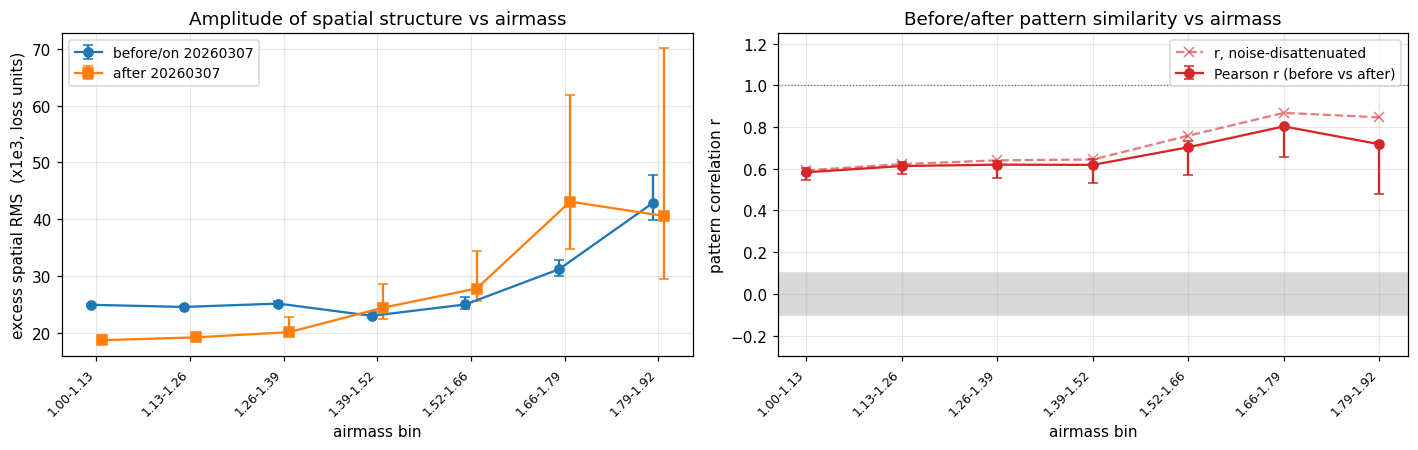

In [12]:
v = var_result.dropna(subset=["r"]).copy()
xc = np.arange(len(v))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))

ax1.errorbar(xc - 0.06, v.exRMS_b * 1e3,
             yerr=[(v.exRMS_b - v.exRMS_b_lo) * 1e3, (v.exRMS_b_hi - v.exRMS_b) * 1e3],
             fmt="o-", capsize=3, label=f"before/on {SPLIT_NIGHT}")
ax1.errorbar(xc + 0.06, v.exRMS_a * 1e3,
             yerr=[(v.exRMS_a - v.exRMS_a_lo) * 1e3, (v.exRMS_a_hi - v.exRMS_a) * 1e3],
             fmt="s-", capsize=3, label=f"after {SPLIT_NIGHT}")
ax1.set_xticks(xc); ax1.set_xticklabels(v.airmass, rotation=45, ha="right", fontsize=8)
ax1.set_xlabel("airmass bin"); ax1.set_ylabel("excess spatial RMS  (x1e3, loss units)")
ax1.set_title("Amplitude of spatial structure vs airmass")
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

ax2.axhspan(-0.1, 0.1, color="0.85", zorder=0)
ax2.errorbar(xc, v.r, yerr=[v.r - v.r_lo, v.r_hi - v.r], fmt="o-", color="C3",
             capsize=3, label="Pearson r (before vs after)")
ax2.plot(xc, v.r_dis, "x--", color="C3", alpha=0.6, label="r, noise-disattenuated")
ax2.axhline(1.0, color="0.4", lw=0.8, ls=":")
ax2.set_ylim(-0.3, 1.25)
ax2.set_xticks(xc); ax2.set_xticklabels(v.airmass, rotation=45, ha="right", fontsize=8)
ax2.set_xlabel("airmass bin"); ax2.set_ylabel("pattern correlation r")
ax2.set_title("Before/after pattern similarity vs airmass")
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Interpreting the airmass trend: platemaker upgrade vs DAR

Two facts from Sections 5–6, and a puzzle:
- **Amplitude of the spatial structure grows strongly with airmass** (left plot, both epochs).
- **The before/after patterns become *more* similar at high airmass** (Pearson r rises from
  ~0.58 at low airmass to ~0.80 by airmass 1.7; the flat-r hypothesis is rejected at
  χ²=22.5/6 dof, p≈1e-3, and a weighted line has slope 0.030±0.007 per bin, 4.2σ from zero).

**The puzzle.** Since ~2026-03-07 a different platemaker (positioning software) is in use, one
that positions *better at high airmass*. Naively that should make the before/after patterns
**diverge** at high airmass (the new one fixes a high-airmass error the old one had), i.e. r
should *drop*. It does the opposite.

**Resolution — r measures shape, not amplitude, and the high-airmass shape is DAR:**
- Pearson r on mean-subtracted maps is **scale-free**: multiply either map by a constant and r
  is unchanged. So anything the platemaker changes in the *amplitude* of the loss is invisible
  to r; only a *differently shaped* component can lower it.
- The high-airmass loss shape is dominated by **DAR acting during the 20-min exposure and
  across wavelength** — an atmospheric drift along the parallactic axis that a better *static*
  placement does not remove. It has the same shape in both epochs, so where it dominates
  (high airmass) both epochs look alike → high r.
- A platemaker that "does better at high airmass" is improving its **refraction** handling,
  which is **collinear with DAR** (same parallactic axis). Improving it reduces the *amplitude*
  along that axis but does not rotate the pattern → same shape → r unaffected. To lower r it
  would have had to add a residual along a *different* axis, which a refraction fix does not do.

**Consequence:** the platemaker improvement should show up in the **amplitude / mean loss**
(Section 8, test #1), not in r. The cleanest discriminator — does the dipole rotate *with the
parallactic angle* (→ DAR) or stay fixed in focal-plane coordinates (→ instrument)? — is
**not possible offline**: the dataset has no pointing columns (no RA/Dec/HA/parallactic angle,
no rotator angle; only `airmass`, which gives the zenith-distance magnitude but not its
direction). That test needs the NERSC/KPNO data sources.

## 8. Test #1 — mean loss vs airmass, before vs after (amplitude)

If the new platemaker reduced high-airmass positioning error, the **net (mean) loss** at high
airmass should drop after 2026-03-07. We compare the star-weighted mean `loss` per airmass bin,
before vs after, with exposure-level bootstrap CIs. Because the after-sample has somewhat worse
seeing in places (and seeing drives fiber loss), we also show the before-sample **standardized
to the after-sample's seeing distribution** (direct standardization over 0.15-arcsec seeing
bins) — if the before/after gap survives that reweighting, it is not a seeing artifact.

In [13]:
SEE_EDGES = np.arange(0.6, 3.0, 0.15)
N_BOOT_AMP = 400
_RNG_AMP = np.random.default_rng(7)


def _exp_sum_count(d):
    g = pd.DataFrame({"e": d.EXPID.values, "loss": d.loss.values}).groupby("e").loss
    a = g.agg(["sum", "count"])
    return a["sum"].values, a["count"].values


def boot_mean_loss(d, n_boot=N_BOOT_AMP, rng=_RNG_AMP):
    """Star-weighted mean loss with exposure-bootstrap 5-95% CI."""
    s, c = _exp_sum_count(d)
    n = len(s)
    pt = s.sum() / c.sum()
    draws = [(s * w).sum() / (c * w).sum()
             for w in (rng.multinomial(n, np.full(n, 1.0 / n)).astype(float)
                       for _ in range(n_boot))]
    lo, hi = np.percentile(draws, [5, 95])
    return pt, lo, hi


def seeing_standardized_before(bb, aa, edges=SEE_EDGES):
    """Before mean loss reweighted to after's seeing distribution (non-NaN seeing)."""
    bb = bb.dropna(subset=["seeing"]); aa = aa.dropna(subset=["seeing"])
    bmean = bb.groupby(pd.cut(bb.seeing, edges), observed=False).loss.mean()
    acount = aa.groupby(pd.cut(aa.seeing, edges), observed=False).loss.count()
    m = pd.DataFrame({"bmean": bmean, "acount": acount}).dropna()
    w = m.acount / m.acount.sum()
    return float((m.bmean * w).sum())


recs = []
for lo, hi in zip(AIRMASS_EDGES[:-1], AIRMASS_EDGES[1:]):
    bb = before[(before.airmass >= lo) & (before.airmass < hi)]
    aa = after[(after.airmass >= lo) & (after.airmass < hi)]
    mb, mbl, mbh = boot_mean_loss(bb)
    ma, mal, mah = boot_mean_loss(aa)
    recs.append(dict(airmass=f"{lo:.2f}-{hi:.2f}",
                     meanB=mb, meanB_lo=mbl, meanB_hi=mbh,
                     meanB_seeadj=seeing_standardized_before(bb, aa),
                     meanA=ma, meanA_lo=mal, meanA_hi=mah,
                     seeingB=bb.seeing.mean(), seeingA=aa.seeing.mean(),
                     n_exp_after=aa.EXPID.nunique()))
amp = pd.DataFrame(recs)

disp = amp.copy()
for c in ["meanB", "meanB_lo", "meanB_hi", "meanB_seeadj", "meanA", "meanA_lo", "meanA_hi"]:
    disp[c] = (disp[c] * 1e3).round(2)
disp["seeingB"] = disp["seeingB"].round(2); disp["seeingA"] = disp["seeingA"].round(2)
print("Mean loss vs airmass (x1e3 loss units); exposure-bootstrap 5-95% CI")
print("meanB_seeadj = before reweighted to after's seeing distribution\n")
disp[["airmass", "meanB", "meanB_lo", "meanB_hi", "meanB_seeadj",
      "meanA", "meanA_lo", "meanA_hi", "seeingB", "seeingA", "n_exp_after"]]

Mean loss vs airmass (x1e3 loss units); exposure-bootstrap 5-95% CI
meanB_seeadj = before reweighted to after's seeing distribution



,airmass,meanB,meanB_lo,meanB_hi,meanB_seeadj,meanA,meanA_lo,meanA_hi,seeingB,seeingA,n_exp_after
0,1.00-1.13,0.34,0.28,0.41,0.40,0.57,0.36,0.78,1.08,1.13,629
1,1.13-1.26,-0.13,-0.22,-0.04,-0.13,0.94,0.70,1.17,1.13,1.18,496
2,1.26-1.39,0.07,-0.06,0.21,-0.00,0.95,0.52,1.44,1.15,1.20,241
3,1.39-1.52,0.62,0.39,0.84,0.38,2.15,1.53,2.73,1.16,1.11,180
4,1.52-1.66,0.87,0.53,1.22,0.71,3.46,1.96,5.07,1.16,1.22,56
5,1.66-1.79,2.90,2.42,3.39,2.45,5.67,3.31,8.39,1.15,1.30,32
6,1.79-1.92,6.69,5.69,7.98,4.55,9.16,5.07,14.58,1.26,1.25,19
7,1.92-2.05,6.49,3.05,10.37,5.42,29.13,17.38,47.83,1.20,1.14,4


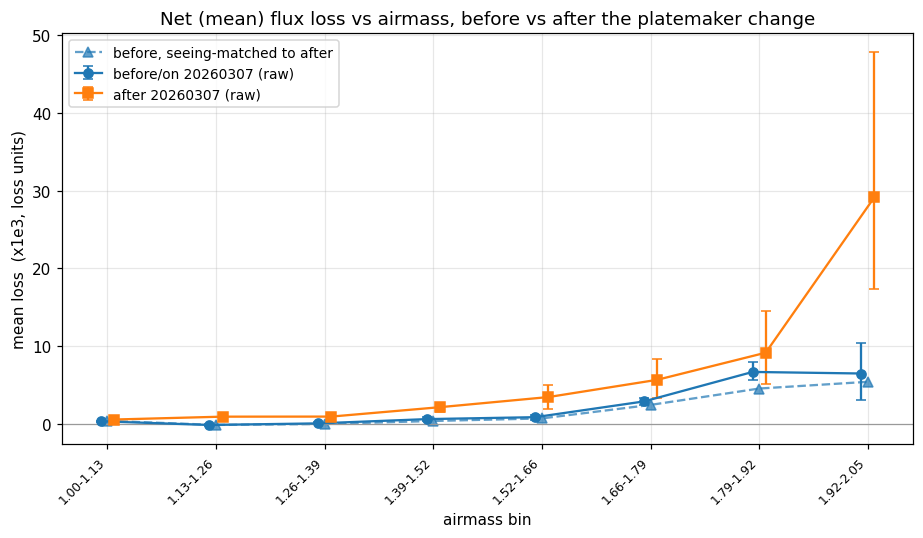

In [14]:
x = np.arange(len(amp))
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.errorbar(x - 0.06, amp.meanB * 1e3,
            yerr=[(amp.meanB - amp.meanB_lo) * 1e3, (amp.meanB_hi - amp.meanB) * 1e3],
            fmt="o-", capsize=3, label=f"before/on {SPLIT_NIGHT} (raw)")
ax.plot(x, amp.meanB_seeadj * 1e3, "^--", color="C0", alpha=0.7,
        label="before, seeing-matched to after")
ax.errorbar(x + 0.06, amp.meanA * 1e3,
            yerr=[(amp.meanA - amp.meanA_lo) * 1e3, (amp.meanA_hi - amp.meanA) * 1e3],
            fmt="s-", color="C1", capsize=3, label=f"after {SPLIT_NIGHT} (raw)")
ax.axhline(0, color="0.6", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(amp.airmass, rotation=45, ha="right", fontsize=8)
ax.set_xlabel("airmass bin"); ax.set_ylabel("mean loss  (x1e3, loss units)")
ax.set_title("Net (mean) flux loss vs airmass, before vs after the platemaker change")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### What test #1 shows

- **Net loss grows with airmass in both epochs**, as expected if DAR (and/or other
  airmass-driven effects) pull flux off the fiber at high airmass.
- **After 2026-03-07 the mean loss is *higher*, not lower**, and the gap widens with airmass —
  the *opposite* of "better high-airmass positioning reduced the loss." The gap **survives
  seeing-matching** (the dashed before-curve barely moves), so it is not a seeing-composition
  artifact.

The change on 2026-03-07 was the platemaker's **DAR/refraction model** (the exposure-time
assumption, effective wavelength, and field-rotation term were unchanged, and the
flux-calibration pipeline / `RCALIBFRAC` definition was **not** changed). So this loss increase
is a **real positioning effect, not a calibration artifact.** The physical
reading (Section 9 and below): a fiber is fixed for the whole 20+ min exposure while the target
drifts under DAR, so what matters is the **exposure-time-integrated** flux loss; the new DAR
model places fibers such that this integral is larger, most at high airmass where DAR is
strongest. The **low-airmass end is a caveat, not a signal** — at low airmass the platemaker was
validated to give identical positioning before/after (see Section 11), so the small low-airmass
before/after difference is attributed to an **epoch confound** (the "before" and "after" samples
span different years/fields/conditions), not the code change. The airmass-*dependent* growth is
the platemaker-related part; confirming it needs the exposure-time and hour-angle columns
(Section 11).

## 9. Predicting the DAR shape from the equatorial-mount geometry

The Mayall is **equatorially mounted**, so the DESI focal plane is fixed to the sky (North =
+Y = top of these plots, up to the small hexapod field-rotation trim) — there is no alt-az
field rotation. DAR therefore always lies along the **parallactic angle measured from that
fixed focal-plane North**. We can't de-project the individual pointings offline (no HA/Dec in
the dataset), but the equatorial geometry lets us **predict the form, the airmass scaling, and
the axis** of the *stacked* pattern, and fit the rest:

- **Form.** A residual-DAR flux-loss map is `loss ≈ |δ|²/2σ²` with on-fiber offset
  `δ = δ_field(x) + δ₀`: δ_field is the field-differential refraction (linear across the field,
  toward zenith) and δ₀ a residual global offset toward zenith. The cross term gives a
  **dipole** (linear in focal-plane position, along the zenith axis) and `|δ_field|²` a
  **quadrupole**. So we fit `loss ≈ c₀ + (dipole in X,Y) + (quadrupole in X²,Y²,XY)` per
  airmass bin, on the cell-mean maps of the **full (combined) dataset**.
- **Airmass scaling.** The dipole (∝ δ₀·δ_field) should scale as **tan z · sec²z**
  (with sec z = airmass).
- **Axis.** At KPNO the zenith is at Dec ≈ +32°; the footprint is dominated by **south-of-zenith
  (Dec < 32) fields observed near transit**, whose zenith sits toward **+Y (North)**. So the
  stacked dipole should lie along the **N–S (Y) axis** — position angle ≈ 0° or 180°.

What still needs the pointings: the exact stack dilution (a broad parallactic-angle spread
partially cancels the vector dipole, so the fitted amplitude is a lower bound), and the
Dec>32 sign-flip test.

In [15]:
_RNG_DAR = np.random.default_rng(11)
N_BOOT_DAR = 300


def _design_matrix(X, Y):
    """[1, x, y, x^2, y^2, xy] with x,y = focal-plane position scaled by FP_RADIUS."""
    x = X / FP_RADIUS; y = Y / FP_RADIUS
    return np.column_stack([np.ones_like(x), x, y, x * x, y * y, x * y])


def _amp_pa(c):
    """dipole amplitude and position angle (deg from +Y/North, 180 = -Y/South)."""
    return np.hypot(c[1], c[2]), np.degrees(np.arctan2(c[1], c[2])) % 360


@np.errstate(divide="ignore", over="ignore", invalid="ignore")   # silence spurious macOS/Accelerate matmul FP-flags
def fit_dar_template(d, min_count=MIN_COUNT, n_boot=N_BOOT_DAR, rng=_RNG_DAR):
    """Weighted least-squares dipole+quadrupole fit to the cell-mean loss map, with an
    exposure-bootstrap CI on the dipole amplitude and direction. Normal equations (not
    lstsq) to keep it warning-free and let the bootstrap reuse the same projection."""
    t = pd.DataFrame({"e": d.EXPID.values, "k": _cell_key(d),
                      "X": d.X.values, "Y": d.Y.values, "loss": d.loss.values})
    ca = t.groupby("k").agg(X=("X", "mean"), Y=("Y", "mean"),
                            loss=("loss", "mean"), n=("loss", "size"))
    ca = ca[ca.n >= min_count]
    A = _design_matrix(ca.X.values, ca.Y.values)
    w = ca.n.values.astype(float)
    M = np.linalg.solve(A.T @ (A * w[:, None]), (A * w[:, None]).T)   # 6 x ncell: means -> coefs
    y = ca.loss.values
    coef = M @ y
    fitv = A @ coef
    wm = np.average(y, weights=w)
    r2 = 1 - np.sum(w * (y - fitv) ** 2) / np.sum(w * (y - wm) ** 2)
    amp, pa = _amp_pa(coef)
    quad = np.sqrt(coef[3] ** 2 + coef[4] ** 2 + coef[5] ** 2)
    # bootstrap over exposures: cell X,Y (and weights, hence M) fixed; only cell-mean loss varies
    cells = ca.index.values
    g = t[t.k.isin(cells)].groupby(["e", "k"]).loss.agg(["sum", "count"]).reset_index()
    ec, _ = pd.factorize(g.e.values)
    cp = pd.Series(np.arange(len(cells)), index=cells).loc[g.k.values].values
    s, cnt, ne = g["sum"].values, g["count"].values, ec.max() + 1
    amps, pas = [], []
    for _ in range(n_boot):
        we = rng.multinomial(ne, np.full(ne, 1.0 / ne)).astype(float)
        ys = np.bincount(cp, weights=s * we[ec], minlength=len(cells))
        yc = np.bincount(cp, weights=cnt * we[ec], minlength=len(cells))
        yb = np.where(yc > 0, ys / np.where(yc > 0, yc, 1), y)
        a2, p2 = _amp_pa(M @ yb)
        amps.append(a2); pas.append(p2)
    amps, pas = np.array(amps), np.array(pas)
    stat = dict(amp=amp, amp_lo=np.percentile(amps, 5), amp_hi=np.percentile(amps, 95),
                pa=pa, pa_lo=np.percentile(pas, 5), pa_hi=np.percentile(pas, 95),
                quad=quad, r2=r2, amean=float(d.airmass.mean()), ncell=len(ca))
    return stat, ca, coef


dar_fits, recs = {}, []
for lo, hi in zip(AIRMASS_EDGES[:-1], AIRMASS_EDGES[1:]):
    d = df[(df.airmass >= lo) & (df.airmass < hi)]
    stat, ca, coef = fit_dar_template(d)
    stat["airmass"] = f"{lo:.2f}-{hi:.2f}"
    dar_fits[stat["airmass"]] = (ca, coef)
    recs.append(stat)
dar = pd.DataFrame(recs)
dar["pred"] = dar.amean ** 2 * np.sqrt(dar.amean ** 2 - 1)     # tan z * sec^2 z  (sec z = airmass)

disp = dar.copy()
for c in ["amp", "amp_lo", "amp_hi", "quad"]:
    disp[c] = (disp[c] * 1e3).round(2)
for c in ["pa", "pa_lo", "pa_hi"]:
    disp[c] = disp[c].round(1)
disp["r2"] = disp["r2"].round(2)
print("DAR dipole+quadrupole template fit vs airmass (full/combined dataset)")
print("amp, quad in x1e3 loss units; PA in deg from +Y/North (180=South); exposure-bootstrap CI\n")
disp[["airmass", "ncell", "amp", "amp_lo", "amp_hi", "pa", "pa_lo", "pa_hi", "quad", "r2"]]

DAR dipole+quadrupole template fit vs airmass (full/combined dataset)
amp, quad in x1e3 loss units; PA in deg from +Y/North (180=South); exposure-bootstrap CI



,airmass,ncell,amp,amp_lo,amp_hi,pa,pa_lo,pa_hi,quad,r2
0,1.00-1.13,238,17.47,17.09,17.82,178.2,177.2,179.1,103.50,0.74
1,1.13-1.26,238,23.68,23.16,24.22,171.7,170.7,172.7,89.37,0.71
2,1.26-1.39,238,29.77,28.86,30.69,167.3,166.1,168.7,78.03,0.72
3,1.39-1.52,236,31.25,29.50,33.02,160.1,157.6,162.2,56.26,0.67
4,1.52-1.66,235,40.36,37.65,43.50,159.7,157.1,162.8,45.99,0.72
5,1.66-1.79,233,57.63,53.90,61.66,155.9,153.5,158.5,30.32,0.78
6,1.79-1.92,224,78.01,70.74,86.92,153.3,148.0,158.0,55.17,0.83
7,1.92-2.05,129,90.68,50.24,157.05,172.0,149.2,206.2,94.52,0.58


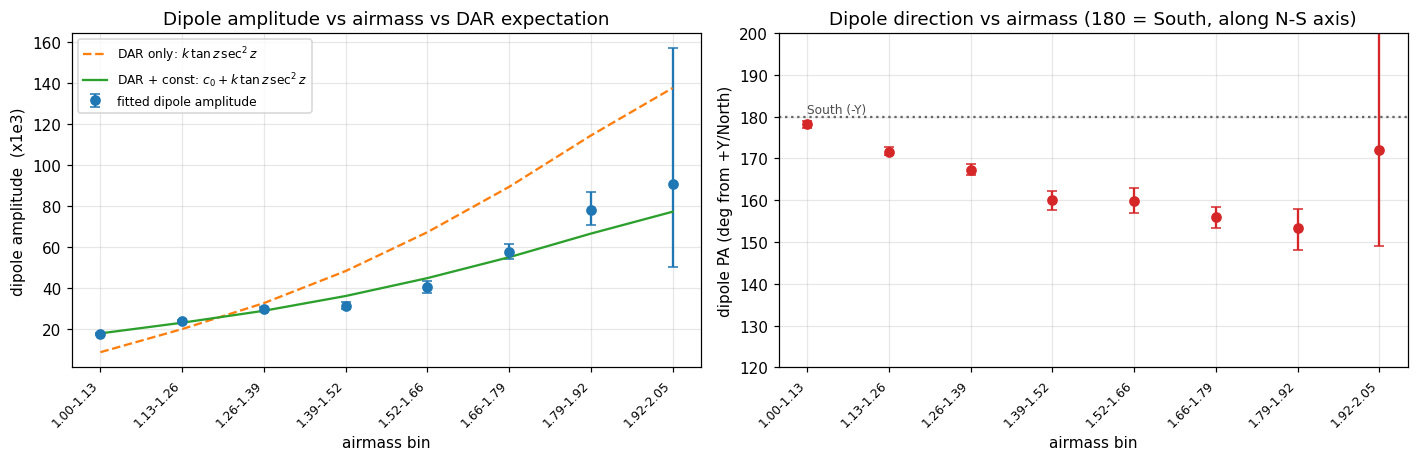

amplitude scaling:  DAR-only k = 0.0218
                    DAR+const: c0 = 13.81e-3 (airmass-independent dipole), k = 0.0100


In [16]:
# Fit the dipole amplitude against the DAR scaling, with and without an airmass-independent term
sig = ((dar.amp_hi - dar.amp_lo) / 2).values
sig = np.where(sig <= 0, sig[sig > 0].mean() if (sig > 0).any() else 1.0, sig)
P, Aobs, W = dar.pred.values, dar.amp.values, 1.0 / sig ** 2
k_only = np.sum(W * Aobs * P) / np.sum(W * P ** 2)                  # amp = k * pred
Xd = np.column_stack([np.ones_like(P), P])
with np.errstate(divide="ignore", over="ignore", invalid="ignore"):   # spurious Accelerate matmul flags
    c0, k = np.linalg.solve(Xd.T @ (Xd * W[:, None]), Xd.T @ (W * Aobs))  # amp = c0 + k * pred

x = np.arange(len(dar))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.3))
ax1.errorbar(x, dar.amp * 1e3,
             yerr=[(dar.amp - dar.amp_lo) * 1e3, (dar.amp_hi - dar.amp) * 1e3],
             fmt="o", capsize=3, label="fitted dipole amplitude")
ax1.plot(x, k_only * P * 1e3, "--", color="C1", label=r"DAR only: $k\,\tan z\,\sec^2 z$")
ax1.plot(x, (c0 + k * P) * 1e3, "-", color="C2",
         label=r"DAR + const: $c_0 + k\,\tan z\,\sec^2 z$")
ax1.set_xticks(x); ax1.set_xticklabels(dar.airmass, rotation=45, ha="right", fontsize=8)
ax1.set_xlabel("airmass bin"); ax1.set_ylabel("dipole amplitude  (x1e3)")
ax1.set_title("Dipole amplitude vs airmass vs DAR expectation")
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

ax2.errorbar(x, dar.pa, yerr=[dar.pa - dar.pa_lo, dar.pa_hi - dar.pa],
             fmt="o", color="C3", capsize=3)
ax2.axhline(180, color="0.4", ls=":"); ax2.axhline(0, color="0.4", ls=":")
ax2.text(0.0, 181, "South (-Y)", fontsize=8, color="0.3")
ax2.set_ylim(120, 200)
ax2.set_xticks(x); ax2.set_xticklabels(dar.airmass, rotation=45, ha="right", fontsize=8)
ax2.set_xlabel("airmass bin"); ax2.set_ylabel("dipole PA (deg from +Y/North)")
ax2.set_title("Dipole direction vs airmass (180 = South, along N-S axis)")
ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"amplitude scaling:  DAR-only k = {k_only:.4f}")
print(f"                    DAR+const: c0 = {c0*1e3:.2f}e-3 (airmass-independent dipole), k = {k:.4f}")

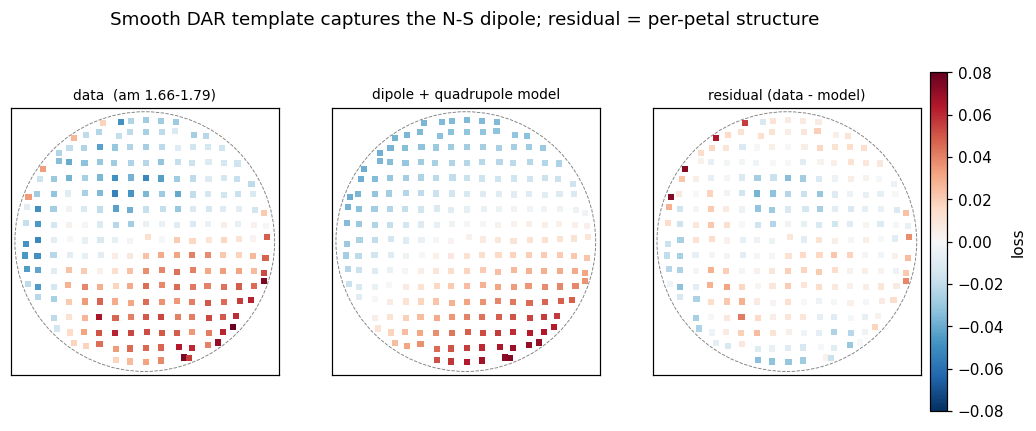

In [17]:
# Data / model / residual for one representative high-airmass bin
bin_label = "1.66-1.79"
ca, coef = dar_fits[bin_label]
with np.errstate(divide="ignore", over="ignore", invalid="ignore"):   # spurious Accelerate matmul flags
    model = _design_matrix(ca.X.values, ca.Y.values) @ coef
data = ca.loss.values
resid = data - model
VM = 0.08


def _cell_scatter(ax, val, title):
    _focalplane_axes(ax)
    ax.scatter(ca.X.values, ca.Y.values, c=val, cmap=CMAP, vmin=-VM, vmax=VM,
               s=16, marker="s", linewidths=0)
    ax.set_title(title, fontsize=9)


fig, axes = plt.subplots(1, 3, figsize=(11, 4))
_cell_scatter(axes[0], data, f"data  (am {bin_label})")
_cell_scatter(axes[1], model, "dipole + quadrupole model")
_cell_scatter(axes[2], resid, "residual (data - model)")
sm = ScalarMappable(norm=Normalize(-VM, VM), cmap=CMAP)
fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.01, label="loss")
fig.suptitle("Smooth DAR template captures the N-S dipole; residual = per-petal structure",
             y=1.02)
plt.show()

### What the template fit shows

- **Direction:** the dipole position angle is **≈155-178° — along the N-S (Y) axis, pointing
  South** (loss increases toward Dec < 32), exactly as the equatorial-mount + KPNO-latitude +
  near-transit geometry predicts. The ~15-25° tilt off pure N-S at mid airmass is expected from
  the spread of hour angles (and would need pointings to model exactly).
- **Amplitude:** from airmass ~1.4 up, the dipole amplitude tracks the **`tan z · sec²z` DAR
  scaling** closely. There is a **low-airmass excess** over the pure-DAR curve, well fit by
  adding an **airmass-independent constant** dipole `c₀` — i.e. a residual instrumental/
  positioning dipole that dominates when DAR is weak and is exactly the kind of term a platemaker
  change could move (Section 7-8).
- **Structure explained:** R² ≈ 0.67-0.83 — the smooth dipole+quadrupole template accounts for
  most of the spatial variance; the **residual is the discrete per-petal calibration pattern**
  (right panel of the triptych), cleanly separated from the DAR component.

So without any pointing information we recover a pattern whose **shape, airmass scaling, and
axis all match the DAR prediction from the equatorial geometry** — strong circumstantial support
for a DAR origin of the smooth component — while isolating a small airmass-independent dipole and
the per-petal term as the non-DAR residuals. Confirming DAR outright (the parallactic-angle
rotation and the Dec>32 sign flip) still needs the pointing columns.

## 10. Did the platemaker change the *non-DAR* part? — split the template

Section 9 separated the loss dipole into a **DAR term** (∝ tan z·sec²z) and an
**airmass-independent term c₀**. If the new platemaker (since 2026-03-07) improved positioning,
the natural expectation is: the atmospheric **DAR slope k unchanged** (the atmosphere doesn't
care about the software) while the **instrumental/positioning dipole c₀ shrinks**. We refit the
dipole template separately for the before and after samples and fit each amplitude curve to
`A(z) = c₀ + k·tan z·sec²z`.

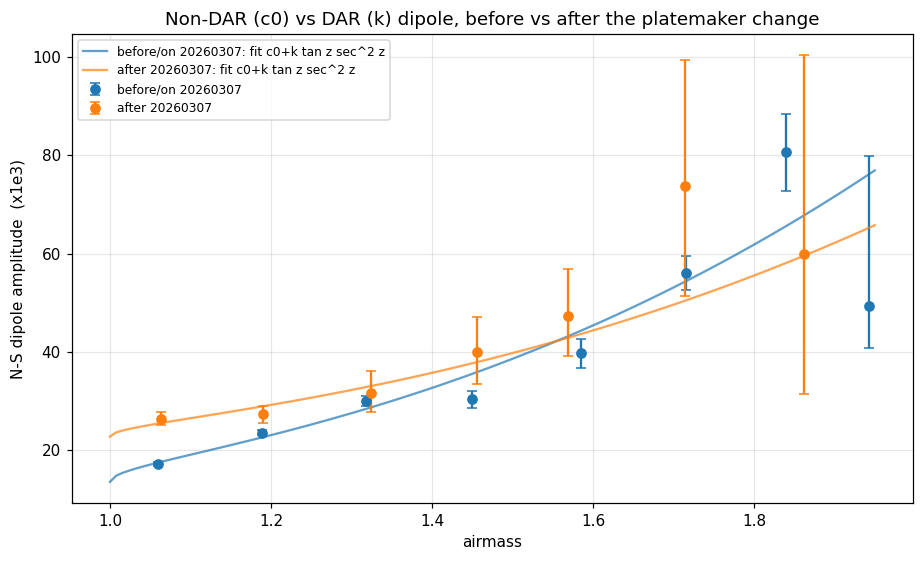

before:  c0 = 13.48 +/- 0.43 (x1e3),   k = 0.0100 +/- 0.0005
after :  c0 = 22.70 +/- 1.75 (x1e3),   k = 0.0068 +/- 0.0020
Delta c0 (after - before) = +9.22 +/- 1.80 (x1e3)


In [18]:
def _dar_amp_curve(sub, min_cells=15):
    rows = []
    for lo, hi in zip(AIRMASS_EDGES[:-1], AIRMASS_EDGES[1:]):
        d = sub[(sub.airmass >= lo) & (sub.airmass < hi)]
        try:
            stat, _, _ = fit_dar_template(d)
        except np.linalg.LinAlgError:
            continue
        if stat["ncell"] < min_cells:
            continue
        stat["airmass"] = f"{lo:.2f}-{hi:.2f}"
        rows.append(stat)
    t = pd.DataFrame(rows)
    t["pred"] = t.amean ** 2 * np.sqrt(t.amean ** 2 - 1)     # tan z * sec^2 z
    return t


def _fit_c0_k(t):
    """Weighted fit of amplitude = c0 + k*pred; returns c0, k and their 1-sigma errors."""
    P, Aobs = t.pred.values, t.amp.values
    sd = ((t.amp_hi - t.amp_lo) / 2).values
    sd = np.where(sd <= 0, np.nanmean(sd[sd > 0]) if (sd > 0).any() else 1.0, sd)
    W = 1.0 / sd ** 2
    X = np.column_stack([np.ones_like(P), P])
    cov = np.linalg.inv(X.T @ (X * W[:, None]))
    c0, k = cov @ (X.T @ (W * Aobs))
    return c0, k, np.sqrt(cov[0, 0]), np.sqrt(cov[1, 1])


amp_before = _dar_amp_curve(before)
amp_after = _dar_amp_curve(after)
c0b, kb, c0be, kbe = _fit_c0_k(amp_before)
c0a, ka, c0ae, kae = _fit_c0_k(amp_after)

ag = np.linspace(1.0, 1.95, 120)
predg = ag ** 2 * np.sqrt(ag ** 2 - 1)
fig, ax = plt.subplots(figsize=(8.5, 5.2))
for t, c0, k, color, lab in [(amp_before, c0b, kb, "C0", f"before/on {SPLIT_NIGHT}"),
                             (amp_after, c0a, ka, "C1", f"after {SPLIT_NIGHT}")]:
    ax.errorbar(t.amean, t.amp * 1e3,
                yerr=[(t.amp - t.amp_lo) * 1e3, (t.amp_hi - t.amp) * 1e3],
                fmt="o", color=color, capsize=3, label=lab)
    ax.plot(ag, (c0 + k * predg) * 1e3, "-", color=color, alpha=0.7,
            label=f"{lab}: fit c0+k tan z sec^2 z")
ax.set_xlabel("airmass"); ax.set_ylabel("N-S dipole amplitude  (x1e3)")
ax.set_title("Non-DAR (c0) vs DAR (k) dipole, before vs after the platemaker change")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"before:  c0 = {c0b*1e3:5.2f} +/- {c0be*1e3:.2f} (x1e3),   k = {kb:.4f} +/- {kbe:.4f}")
print(f"after :  c0 = {c0a*1e3:5.2f} +/- {c0ae*1e3:.2f} (x1e3),   k = {ka:.4f} +/- {kae:.4f}")
print(f"Delta c0 (after - before) = {(c0a-c0b)*1e3:+.2f} +/- {np.hypot(c0ae,c0be)*1e3:.2f} (x1e3)")

### What the split shows

We attempted to separate the two before/after: the DAR slope `k` (should be unchanged — the
atmosphere doesn't care about the software) and the airmass-independent term `c₀`.

- **The DAR term `k` cannot be constrained in the after sample**: the after high-airmass bins have
  very few exposures and noise-dominated, non-monotonic amplitudes (big error bars in the figure),
  so this split cannot measure whether the atmospheric term changed. This is the regime that
  actually matters, and it is exactly where the after statistics give out.
- **The airmass-independent term `c₀` appears larger after**, but we do **not** interpret this as a
  platemaker effect. At low airmass the platemaker was validated to give *identical* positioning
  before and after (Section 11), so a low-airmass before/after difference cannot come from the
  code change — it is an **epoch confound**: the "before" sample spans years of observing while
  "after" is a few recent months, differing in fields, seasons and conditions. We therefore
  **drop the low-airmass difference** from the platemaker interpretation.

The takeaway from the split is narrow but honest: the *airmass-dependent* (DAR-timing) part — the
part that would carry a real platemaker effect — is **not measurable offline** with the thin
after-sample, and the airmass-independent part is a confound. The evidence that the platemaker
change increased loss therefore rests on Section 8 (net loss higher after, growing with airmass)
plus the physical picture in Sections 9 and 11, not on this decomposition.

## 11. Summary and next steps (need the NERSC/KPNO data sources)

**What this notebook established offline, from the local dataset alone:**

1. **Reproduced** the archived NERSC figures (all-exposures scatter; seeing×airmass grid;
   post-2026-03-07 airmass row) from `notebooks/data/dar_calibstars_dataset.parquet`.
2. **Net (mean) flux loss is higher *after* 2026-03-07**, the gap **grows with airmass**, and it
   **survives seeing-matching** — the high-airmass loss got worse, not better, across the
   platemaker change (Section 8). This is the central empirical result.
3. **The smooth loss pattern is DAR.** From the equatorial-mount geometry we predicted its form,
   axis, and airmass scaling; the fit confirms a dipole **along the N–S / zenith axis** with
   amplitude following **tan z·sec²z**, and R²≈0.7–0.8 with the per-petal term as residual
   (Section 9). The before/after pattern correlation also rises with airmass (Section 6),
   i.e. the shared airmass-driven (DAR) component increasingly dominates.

**Interpretation.** The change on 2026-03-07 was the platemaker's **DAR/refraction model**
(exposure-time assumption, effective wavelength, field-rotation term all unchanged;
`RCALIBFRAC`/flux calibration unchanged) — so the increase is a **real positioning effect, not
calibration.** A fiber is fixed for the whole 20+ min exposure while the target
drifts under DAR, so what matters is the **exposure-time-integrated** loss, minimized not at the
instantaneous position but at a point along the drift track. Both codes position for the assumed
exposure **midpoint**; the new DAR model evidently places fibers where the *integrated* DAR loss
is larger, worst at high airmass. The **dither validation is structurally blind to this**: it
uses short (3-min) repositioned exposures near the meridian (validated old=new at low airmass;
new checked at Dec −20/−25/−30, airmass ~1.6–2.1, near transit) — the minimal-integrated-drift
regime — whereas the loss accrues in long, fixed-fiber, **off-meridian** exposures (cf. the
atmospheric-dispersion residuals already noted at high airmass by Schlafly et al. 2024,
arXiv:2403.05688). The small **low-airmass** before/after difference is **not** attributed to the
platemaker (positioning validated identical there) — it is an epoch confound and is dropped.

**Next step — confirm with per-exposure pointing/timing (needs NERSC/KPNO).** The exposure list
`notebooks/dar_exposure_list.csv` (all 24,630 EXPIDs, with night/airmass/seeing/epoch) is provided
for a KPNO-database join. The decisive test:

| column(s) to fetch per EXPID | enables |
|---|---|
| `RA`, `Dec`, `MJD`(start) + `EXPTIME`, or precomputed `HA` / **parallactic angle** | **HA-dependence test** — at fixed airmass the excess should grow with |HA| / integrated DAR drift; near-meridian exposures should match the dither validation. Also lets us reconstruct the DAR track over each exposure. |
| **EXPTIME** and **effective/`totteff`** exposure time | DAR accumulates over the integration — control the loss comparison and test the exposure-time dependence. |
| **hexapod rotator angle / update rate** | field-rotation coupling; maps sky parallactic direction onto the focal plane (ties to `FIELD_ROTATION_REPORT.md`). |

Complementary and independent of our data: **run the old and new DAR models on the same fields**
and compare the predicted midpoint fiber placements and the integrated-loss penalty they imply —
a direct confirmation the platemaker author can do without the pooled dataset.